# Convolutional Neural Network (CNN) Model

## 1. Imports and configuration

In [1]:
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
)

import tensorflow as tf
from tensorflow.keras import layers, callbacks, models

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

sns.set_theme(style="whitegrid")

DATA_DIR = Path("datasets")
RESULTS_DIR = Path("results")
MODEL_DIR = Path("models")
RESULTS_DIR.mkdir(exist_ok=True)
MODEL_DIR.mkdir(exist_ok=True)

MAX_TOKENS = 30000
MAX_LEN = 256
EMBEDDING_DIM = 128
BATCH_SIZE = 64
EPOCHS = 8
THRESHOLD = 0.50

## 2. Load train/test data and create validation split

In [2]:
train_df = pd.read_csv(DATA_DIR / "train_hotel_reviews.csv")
test_df = pd.read_csv(DATA_DIR / "test_hotel_reviews.csv")

required_cols = {"review_text", "sentiment"}
missing = required_cols - set(train_df.columns)
if missing:
    raise ValueError(f"Missing required columns in training data: {missing}")

train_df["review_text"] = train_df["review_text"].fillna("").astype(str)
test_df["review_text"] = test_df["review_text"].fillna("").astype(str)

train_part, val_df = train_test_split(
    train_df,
    test_size=0.15,
    random_state=SEED,
    stratify=train_df["sentiment"],
)

X_train = train_part["review_text"].values
y_train = train_part["sentiment"].astype(int).values

X_val = val_df["review_text"].values
y_val = val_df["sentiment"].astype(int).values

X_test = test_df["review_text"].values
y_test = test_df["sentiment"].astype(int).values

print("Train shape:", train_part.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)
print("Train class distribution:")
print(pd.Series(y_train).value_counts(normalize=True).sort_index().round(3))

Train shape: (54482, 9)
Validation shape: (9615, 9)
Test shape: (16025, 9)
Train class distribution:
0    0.286
1    0.714
Name: proportion, dtype: float64


## 3. Build TensorFlow input pipeline

In [3]:
def make_text_dataset(texts, labels, batch_size=BATCH_SIZE, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((texts, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(texts), seed=SEED, reshuffle_each_iteration=True)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

train_ds = make_text_dataset(X_train, y_train, shuffle=True)
val_ds = make_text_dataset(X_val, y_val)
test_ds = make_text_dataset(X_test, y_test)

vectorizer = layers.TextVectorization(
    max_tokens=MAX_TOKENS,
    output_mode="int",
    output_sequence_length=MAX_LEN,
    standardize="lower_and_strip_punctuation",
)

# Adapt only on the training text to avoid leaking validation/test information.
vectorizer.adapt(tf.data.Dataset.from_tensor_slices(X_train).batch(BATCH_SIZE))

print("Vocabulary size used by CNN:", len(vectorizer.get_vocabulary()))

Vocabulary size used by CNN: 30000


## 4. Define the CNN model

In [4]:
def build_cnn_model():
    text_input = layers.Input(shape=(1,), dtype=tf.string, name="review_text")
    x = vectorizer(text_input)
    x = layers.Embedding(
        input_dim=MAX_TOKENS,
        output_dim=EMBEDDING_DIM,
        name="token_embedding",
    )(x)
    x = layers.Conv1D(filters=128, kernel_size=5, activation="relu", padding="same")(x)
    x = layers.GlobalMaxPooling1D()(x)
    x = layers.Dropout(0.40)(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.30)(x)
    output = layers.Dense(1, activation="sigmoid", name="sentiment_probability")(x)

    model = models.Model(inputs=text_input, outputs=output, name="cnn_hotel_sentiment")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
            tf.keras.metrics.AUC(name="auc"),
        ],
    )
    return model

cnn_model = build_cnn_model()
cnn_model.summary()

Model: "cnn_hotel_sentiment"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ review_text (InputLayer)        │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ text_vectorization              │ (None, 256)            │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ token_embedding (Embedding)     │ (None, 256, 128)       │     3,840,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 256, 128)       │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sentiment_probability (Dense)   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,930,369 (14.99 MB)

 Trainable params: 3,930,369 (14.99 MB)

 Non-trainable params: 0 (0.00 B)

## 5. Train the model

In [6]:
classes = np.unique(y_train)
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weight = {int(cls): float(weight) for cls, weight in zip(classes, weights)}
print("Class weights:", class_weight)

class ASCIILogger(callbacks.Callback):
    """Print epoch summaries using plain ASCII to avoid Windows cp1252 Unicode errors."""
    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        parts = [f"epoch={epoch + 1}"]
        for key in [
            "loss", "accuracy", "precision", "recall", "auc",
            "val_loss", "val_accuracy", "val_precision", "val_recall", "val_auc"
        ]:
            if key in logs:
                parts.append(f"{key}={logs[key]:.4f}")
        print(" | ".join(parts))

training_callbacks = [
    callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=2,
        restore_best_weights=True,
    ),
    ASCIILogger(),
]

history = cnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weight,
    callbacks=training_callbacks,
    verbose=0,
)

history_df = pd.DataFrame(history.history)
history_df.to_csv(RESULTS_DIR / "cnn_training_history.csv", index=False)

cnn_model.save_weights(str(MODEL_DIR / "cnn_hotel_sentiment.weights.h5"))
print("Saved CNN weights to:", MODEL_DIR / "cnn_hotel_sentiment.weights.h5")

history_df.tail()

Class weights: {0: 1.7475622273543752, 1: 0.7003908057798118}
epoch=1 | loss=0.2997 | accuracy=0.8741 | precision=0.9482 | recall=0.8713 | auc=0.9451 | val_loss=0.3232 | val_accuracy=0.8549 | val_precision=0.9329 | val_recall=0.8585 | val_auc=0.9339
epoch=2 | loss=0.2052 | accuracy=0.9172 | precision=0.9683 | recall=0.9140 | auc=0.9739 | val_loss=0.3468 | val_accuracy=0.8541 | val_precision=0.9307 | val_recall=0.8596 | val_auc=0.9268
epoch=3 | loss=0.1348 | accuracy=0.9454 | precision=0.9817 | recall=0.9410 | auc=0.9884 | val_loss=0.3854 | val_accuracy=0.8613 | val_precision=0.9113 | val_recall=0.8925 | val_auc=0.9204
Saved CNN weights to: models\cnn_hotel_sentiment.weights.h5


,accuracy,auc,loss,precision,recall,val_accuracy,val_auc,val_loss,val_precision,val_recall
0,0.874124,0.945136,0.299686,0.948181,0.871291,0.854914,0.933868,0.323154,0.932880,0.858537
1,0.917202,0.973877,0.205226,0.968267,0.913971,0.854082,0.926835,0.346801,0.930746,0.859557
2,0.945358,0.988364,0.134751,0.981655,0.941045,0.861258,0.920367,0.385444,0.911336,0.892483


## 6. Plot training curves

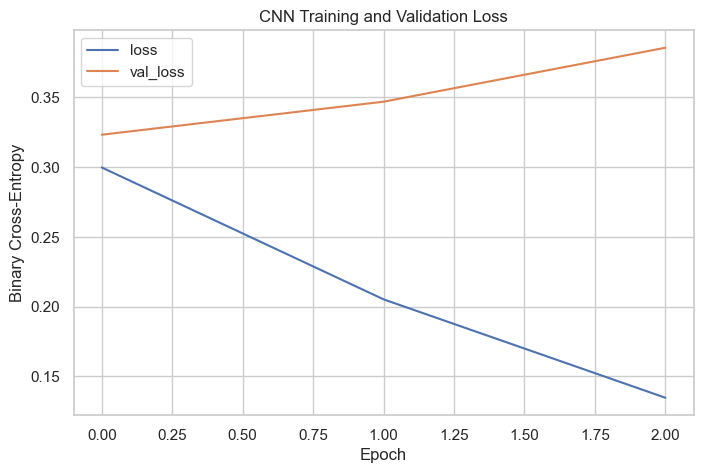

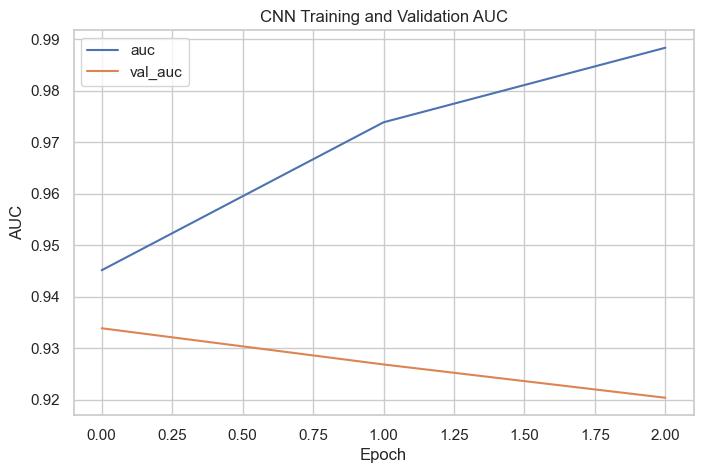

In [7]:
history_df[["loss", "val_loss"]].plot(figsize=(8, 5))
plt.title("CNN Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy")
plt.show()

history_df[["auc", "val_auc"]].plot(figsize=(8, 5))
plt.title("CNN Training and Validation AUC")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.show()

## 7. Evaluate on the held-out test set

251/251 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
Model        CNN Text Classifier
Accuracy                0.854789
Precision               0.934325
Recall                  0.856818
F1                      0.893894
ROC_AUC                 0.928157
dtype: object

Classification report:
              precision    recall  f1-score   support

           0       0.70      0.85      0.77      4585
           1       0.93      0.86      0.89     11440

    accuracy                           0.85     16025
   macro avg       0.82      0.85      0.83     16025
weighted avg       0.87      0.85      0.86     16025



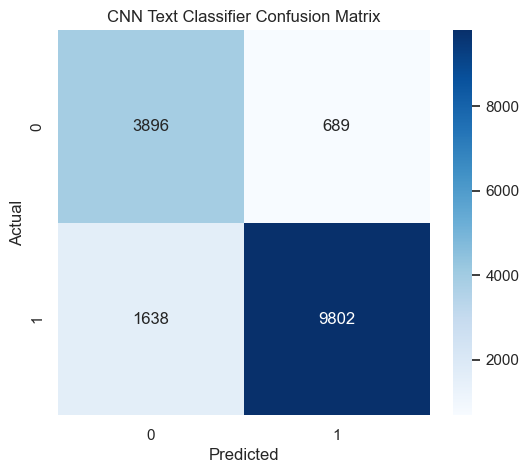

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,CNN Text Classifier,0.8548,0.9343,0.8568,0.8939,0.9282


In [8]:
def evaluate_binary_classifier(model, dataset, y_true, model_name, threshold=THRESHOLD):
    y_prob = model.predict(dataset).ravel()
    y_pred = (y_prob >= threshold).astype(int)

    metrics = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) == 2 else np.nan,
    }

    print(pd.Series(metrics))
    print("\nClassification report:")
    print(classification_report(y_true, y_pred, zero_division=0))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{model_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    return metrics, y_prob, y_pred

cnn_metrics, cnn_probs, cnn_preds = evaluate_binary_classifier(
    cnn_model,
    test_ds,
    y_test,
    model_name="CNN Text Classifier",
)

cnn_results = pd.DataFrame([cnn_metrics])
cnn_results.to_csv(RESULTS_DIR / "cnn_results.csv", index=False)
cnn_results.round(4)

## 8. Save predictions for later comparison/error analysis

In [9]:
predictions_df = test_df[["review_text", "sentiment"]].copy()
predictions_df["cnn_probability_positive"] = cnn_probs
predictions_df["cnn_prediction"] = cnn_preds
predictions_df.to_csv(RESULTS_DIR / "cnn_test_predictions.csv", index=False)

print("Saved CNN model, metrics, training history, and test predictions.")

Saved CNN model, metrics, training history, and test predictions.
